In [11]:
from astropy.io import fits
import matplotlib.pyplot as plt

In [12]:
hdul = fits.open("RT.fits")
hdul.info()

Filename: RT.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      24   (501, 501, 1, 1, 1)   float32   
  1                1 ImageHDU        10   (1, 1, 1, 2)   float32   
  2                1 ImageHDU         9   (1, 1, 1)   float32   
  3                1 ImageHDU         8   (3, 1)   float32   


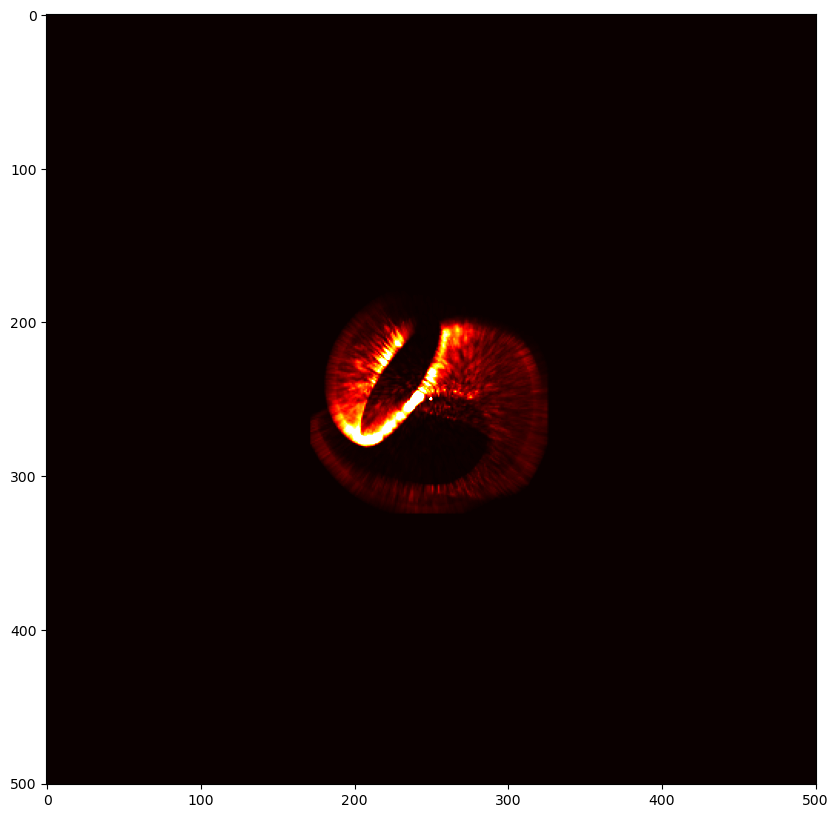

In [20]:
data = hdul[0].data[0][0][0]

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(data[::-1, :], vmax=5e-18, cmap='hot')


In [14]:
file = "Data/JWST/F2550W_hdr/i3_result_i2d.fits"
jwst = fits.open(file)
jwst.info()

Filename: Data/JWST/F2550W_hdr/i3_result_i2d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     347   ()      
  1  SCI           1 ImageHDU        75   (1204, 1160)   float32   
  2  ERR           1 ImageHDU        10   (1204, 1160)   float32   
  3  CON           1 ImageHDU        10   (1204, 1160, 1)   int32   
  4  WHT           1 ImageHDU         9   (1204, 1160)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (1204, 1160)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (1204, 1160)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (1204, 1160)   float32   
  8  HDRTAB        1 BinTableHDU    842   8R x 416C   [23A, 5A, 3A, 18A, 7A, 13A, 3A, 5A, 6A, 7A, 10A, 4A, L, D, D, D, D, 9A, 9A, 42A, 10A, 2A, D, 33A, D, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 2A, L, 12A, 4A, 2A, 26A, 20A, 27A, 10A, K, L, L, L, L, 15A, 15A, 5A, D, D, D, D, D, D, 27A, D, D, D, 4A, 8A, D, D, 6A, D, D, D, D, D, D, D, 4A, D, D, 

In [15]:
jwst[1].header

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 1204                                                  
NAXIS2  =                 1160                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
EXTNAME = 'SCI     '           / extension name                                 
MJD-BEG =    60515.19692832222 / [d] exposure start time in MJD                 
MJD-AVG =   60515.209125490685 / [d] exposure mid-point in MJD                  
MJD-END =   60515.226510243054 / [d] exposure end time in MJD                   
TDB-BEG =   60515.200903944075 / [d] TDB time of exposure start in MJD          
TDB-MID =   60515.2131002894

Set OBSGEO-B to   -33.566140 from OBSGEO-[XYZ].
Set OBSGEO-H to 1698829842.623 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


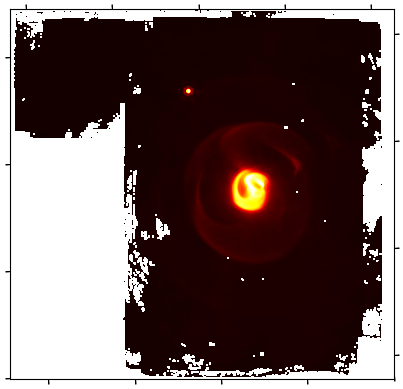

In [16]:
import warnings
from matplotlib import pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS, FITSFixedWarning
from astropy.utils.data import get_pkg_data_filename

filename = get_pkg_data_filename(file)

hdu = fits.open(filename)[1]
with warnings.catch_warnings():
    # Ignore a warning on using DATE-OBS in place of MJD-OBS
    warnings.filterwarnings('ignore', message="'datfix' made the change",
                            category=FITSFixedWarning)
    wcs = WCS(hdu.header, key=' ')

fig, ax = plt.subplots(subplot_kw=dict(projection=wcs), layout=None)
ax.set(xlabel='RA', ylabel='Dec')
ax.imshow(hdu.data, origin='lower', cmap='hot', interpolation=None, norm='log')


plt.show()

In [17]:
wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 240.2109253495828  -51.718045324427656  
CRPIX : 582.0619227404769  595.0840553554492  
PC1_1 PC1_2  : -0.06108433381551325  0.9981326085056609  
PC2_1 PC2_2  : 0.9981326085056609  0.06108433381551325  
CDELT : 3.08079691139728e-05  3.08079691139728e-05  
NAXIS : 1204  1160